In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
def getCSV(name):
    dfl = pd.read_csv(name)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\DwellingsCork.csv') 
print(df)

               Statistic Label Quarter                  Local Electoral Area  \
0     New Dwelling Completions  2012Q1                                 State   
1     New Dwelling Completions  2012Q1  Borris-In-Ossory-Mountmellick, Laois   
2     New Dwelling Completions  2012Q1                     Portlaoise, Laois   
3     New Dwelling Completions  2012Q1   Graiguecullen -Portarlington, Laois   
4     New Dwelling Completions  2012Q1                        Carlow, Carlow   
...                        ...     ...                                   ...   
9013  New Dwelling Completions  2025Q2                    Newbridge, Kildare   
9014  New Dwelling Completions  2025Q2                 Castlecomer, Kilkenny   
9015  New Dwelling Completions  2025Q2                    Kilkenny, Kilkenny   
9016  New Dwelling Completions  2025Q2                     Piltown, Kilkenny   
9017  New Dwelling Completions  2025Q2           Callan-Thomastown, Kilkenny   

        UNIT  VALUE  
0     Number   11

In [27]:
county = "Cork City"
filtered_df = df[df["Local Electoral Area"].str.contains(county)]
filtered_df['Quarter_p'] = pd.PeriodIndex(filtered_df['Quarter'], freq='Q')
filtered_df = filtered_df[filtered_df['Quarter_p'] > '2020Q1']

C:\Users\Tom\AppData\Local\Temp\ipykernel_20620\2363266953.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Quarter_p'] = pd.PeriodIndex(filtered_df['Quarter'], freq='Q')


In [28]:
print(filtered_df)
nw_df = filtered_df[filtered_df["Local Electoral Area"]=="Cork City North West, Cork City"]
ne_df = filtered_df[filtered_df["Local Electoral Area"]=="Cork City North East, Cork City"]
se_df = filtered_df[filtered_df["Local Electoral Area"]=="Cork City South East, Cork City"]
sc_df = filtered_df[filtered_df["Local Electoral Area"]=="Cork City South Central, Cork City"]
sw_df = filtered_df[filtered_df["Local Electoral Area"]=="Cork City South West, Cork City"]

               Statistic Label Quarter                Local Electoral Area  \
5638  New Dwelling Completions  2020Q2     Cork City North West, Cork City   
5639  New Dwelling Completions  2020Q2     Cork City North East, Cork City   
5640  New Dwelling Completions  2020Q2     Cork City South East, Cork City   
5641  New Dwelling Completions  2020Q2  Cork City South Central, Cork City   
5642  New Dwelling Completions  2020Q2     Cork City South West, Cork City   
...                        ...     ...                                 ...   
8978  New Dwelling Completions  2025Q2     Cork City North West, Cork City   
8979  New Dwelling Completions  2025Q2     Cork City North East, Cork City   
8980  New Dwelling Completions  2025Q2     Cork City South East, Cork City   
8981  New Dwelling Completions  2025Q2  Cork City South Central, Cork City   
8982  New Dwelling Completions  2025Q2     Cork City South West, Cork City   

        UNIT  VALUE Quarter_p  
5638  Number     44    2020Q2  

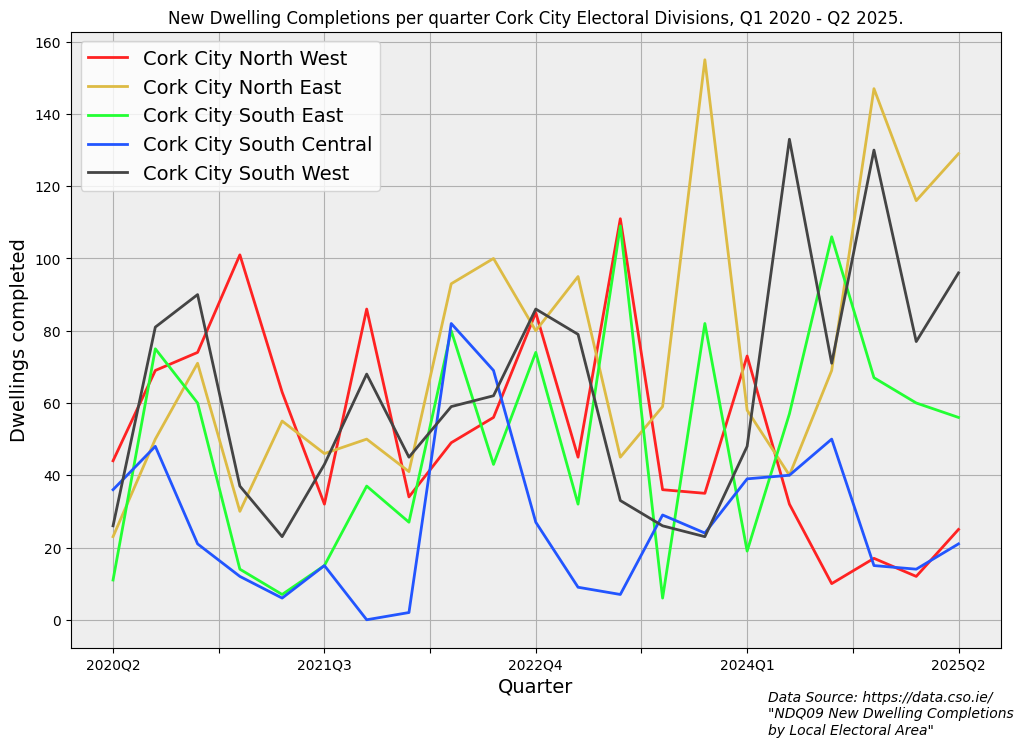

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

nw_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", linewidth=2, color="#F22", ax=ax, label="Cork City North West")
ne_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", linewidth=2, color="#DB4", ax=ax, label="Cork City North East")
se_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", linewidth=2, color="#2F3", ax=ax, label="Cork City South East")
sc_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", linewidth=2, color="#25F", ax=ax, label="Cork City South Central")
sw_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", linewidth=2, color="#444", ax=ax, label="Cork City South West")

title_string = "New Dwelling Completions per quarter Cork City Electoral Divisions, Q1 2020 - Q2 2025."

plt.title(title_string)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('Dwellings completed',fontsize=14)
ax.set_facecolor('#EEEEEE') 
plt.grid(True)

plt.legend(fontsize=14)

plt.text(0.75, -0.14, "Data Source: https://data.cso.ie/\n\"NDQ09 New Dwelling Completions \nby Local Electoral Area\" ", ha='left',
         transform=ax.transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'Cork-Dwellings-2020-2025.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


In [44]:
filtered_df = df[df["Local Electoral Area"].str.contains(county)]
filtered_df = filtered_df[filtered_df["Quarter"]=="2025Q2"]
filtered_df['Local Electoral Area'] = filtered_df['Local Electoral Area'].apply(lambda x: x[:-11])

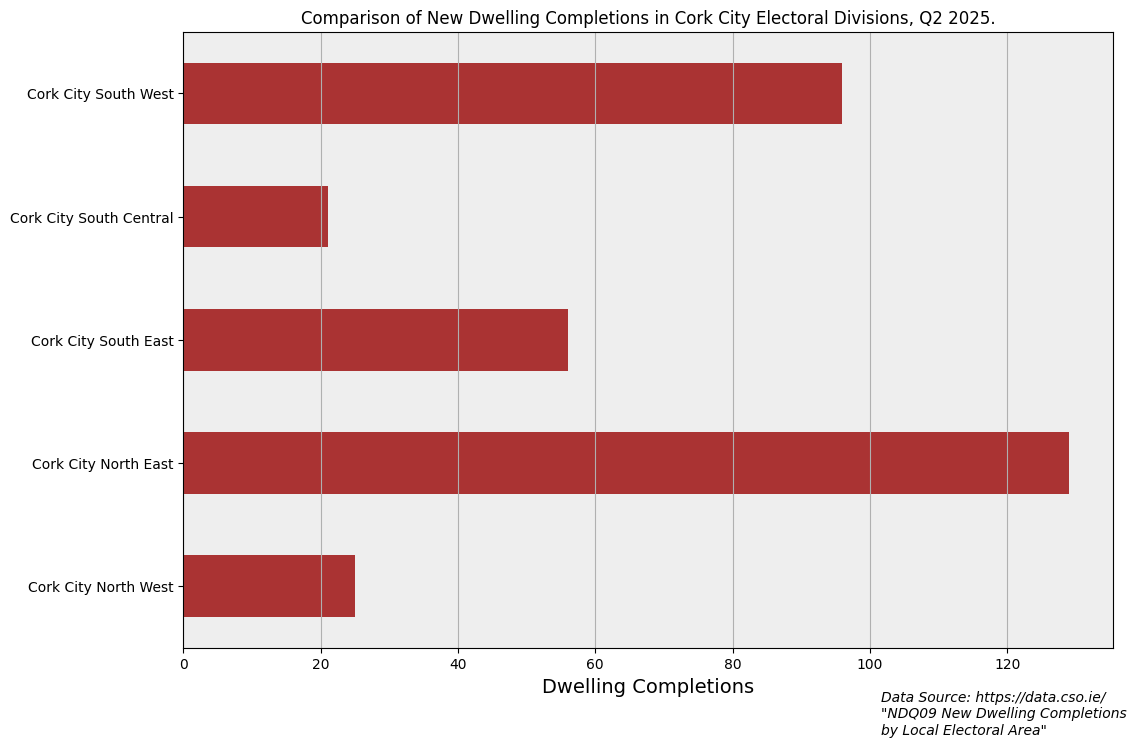

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

filtered_df.plot(x="Local Electoral Area", y="VALUE", kind="barh", color="#A33", ax=ax)

title_string = "Comparison of New Dwelling Completions in Cork City Electoral Divisions, Q2 2025."

plt.title(title_string)
plt.xlabel('Dwelling Completions', fontsize=14)
plt.ylabel('',fontsize=14)
ax.set_facecolor('#EEEEEE') 
plt.grid(True)
plt.grid(axis='y')

legend = plt.legend()
legend.set_visible(False)

plt.text(0.75, -0.14, "Data Source: https://data.cso.ie/\n\"NDQ09 New Dwelling Completions \nby Local Electoral Area\" ", ha='left',
         transform=ax.transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'Cork-Dwellings-Bar-2025Q2.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()
